In [2]:
import os, sys
import time
import csv
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.decomposition import PCA
import warnings
from sklearn.exceptions import ConvergenceWarning

from mgsa.io import samples_from_soils, get_function, get_data
from mgsa.modeling import Model
from mgsa.helpers import plot

### Load in Data

In [3]:
NARG_INFO = {
    "KO": "K00370",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00370_v1.tsv"
}

NIRB_INFO = {
    "KO": "K00362",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00362_v1.tsv"
}

NATIVE_IDXS = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]
NATIVE_PHS = np.array([5.0, 5.3, 5.41, 5.8, 6.15, 6.3, 6.5, 6.75, 6.9,  7.1])
PERTURBED_PHS = np.linspace(3.8, 8.4, 11)

OUTDIR = "../out/model_regression/nar"
IMGDIR = f"{OUTDIR}/images"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(IMGDIR, exist_ok=True)

def texify(param_name):
    return {
        "gamma_A": "\\gamma_{{A}}", 
        "gamma_I": "\\gamma_{{I}}", 
        "r_A": "r_{{A}}", 
        "r_I1": "r_{{I1}}", 
        "r_I2": "r_{{I2}}", 
        "K_A": "K_{{A}}", 
        "K_I": "K_{{I}}", 
        "mu": "\\mu", 
    }[param_name]

t_data_drug = np.linspace(0, 19, 20)

soils = [
    'Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 
    'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'
]



def load_orf_groups(fpath) -> tuple[dict[int:str], np.ndarray[int]]:
    groups = {}
    idxs = []
    with open(fpath, "r") as f:
        csvreader = csv.reader(f, delimiter=" ")
        for row in csvreader:  # process each row
            orf = row[0]
            gidx = int(row[1])
            if gidx in groups:
                groups[gidx].append(orf)
            else:
                groups[gidx] = [orf]
                idxs.append(gidx)
    return groups, np.sort(idxs)

##############################################################################
##  Collect narG data

# Load ORF groups for narG
groups, group_idxs = load_orf_groups(NARG_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}
for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='None', 
            map='09',
        )
        # Subset T0 samples to those of interest
        data_chl_pos_t0 = data_chl_pos_t0[NATIVE_IDXS]
        data_chl_neg_t0 = data_chl_neg_t0[NATIVE_IDXS]

        gidx2exp_chl_pos_t0[gidx].append(data_chl_pos_t0)
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t0[gidx].append(data_chl_neg_t0)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t0[gidx] = np.sum(gidx2exp_chl_pos_t0[gidx], axis=0)
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t0[gidx] = np.sum(gidx2exp_chl_neg_t0[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t0[gidx].shape == (10,), "Wrong shape for t0 pos"
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,11), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t0[gidx].shape == (10,), "Wrong shape for t0 neg"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,11), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nar_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_pos_t9 = np.zeros([10, 11, len(group_idxs)])
nar_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_neg_t9 = np.zeros([10, 11, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nar_exp_chl_pos_t0[...,i] = gidx2exp_chl_pos_t0[gidx]
    nar_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nar_exp_chl_neg_t0[...,i] = gidx2exp_chl_neg_t0[gidx]
    nar_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]

##############################################################################
##  Collect nirB data

# Load ORF groups for nirB
groups, group_idxs = load_orf_groups(NIRB_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}
for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='None', 
            map='09',
        )
        # Subset T0 samples to those of interest
        data_chl_pos_t0 = data_chl_pos_t0[NATIVE_IDXS]
        data_chl_neg_t0 = data_chl_neg_t0[NATIVE_IDXS]

        gidx2exp_chl_pos_t0[gidx].append(data_chl_pos_t0)
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t0[gidx].append(data_chl_neg_t0)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t0[gidx] = np.sum(gidx2exp_chl_pos_t0[gidx], axis=0)
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t0[gidx] = np.sum(gidx2exp_chl_neg_t0[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t0[gidx].shape == (10,), "Wrong shape for t0 pos"
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,11), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t0[gidx].shape == (10,), "Wrong shape for t0 neg"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,11), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nir_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_pos_t9 = np.zeros([10, 11, len(group_idxs)])
nir_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_neg_t9 = np.zeros([10, 11, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nir_exp_chl_pos_t0[...,i] = gidx2exp_chl_pos_t0[gidx]
    nir_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nir_exp_chl_neg_t0[...,i] = gidx2exp_chl_neg_t0[gidx]
    nir_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]


Group 1: 18 ORFs
Group 2: 4 ORFs
Group 3: 14 ORFs
Group 4: 21 ORFs
  Total: 57
Group 1: 24 ORFs
Group 2: 15 ORFs
Group 3: 10 ORFs
Group 4: 13 ORFs
  Total: 62


In [4]:
##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_pos_t0 = nar_exp_chl_pos_t0 / np.sum(nar_exp_chl_pos_t0, -1)[...,None]
nar_rel_exp_chl_pos_t0 = nar_rel_exp_chl_pos_t0[:, np.newaxis, :]
nar_rel_exp_chl_pos_t0 = np.broadcast_to(nar_rel_exp_chl_pos_t0, (10, 11, 4))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t0 = nir_exp_chl_pos_t0 / np.sum(nir_exp_chl_pos_t0, -1)[...,None]
nir_rel_exp_chl_pos_t0 = nir_rel_exp_chl_pos_t0[:, np.newaxis, :]
nir_rel_exp_chl_pos_t0 = np.broadcast_to(nir_rel_exp_chl_pos_t0, (10, 11, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_pos_t9 = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t9 = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_neg_t0 = nar_exp_chl_neg_t0 / np.sum(nar_exp_chl_neg_t0, -1)[...,None]
nar_rel_exp_chl_neg_t0 = nar_rel_exp_chl_neg_t0[:, np.newaxis, :]
nar_rel_exp_chl_neg_t0 = np.broadcast_to(nar_rel_exp_chl_neg_t0, (10, 11, 4))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t0 = nir_exp_chl_neg_t0 / np.sum(nir_exp_chl_neg_t0, -1)[...,None]
nir_rel_exp_chl_neg_t0 = nir_rel_exp_chl_neg_t0[:, np.newaxis, :]
nir_rel_exp_chl_neg_t0 = np.broadcast_to(nir_rel_exp_chl_neg_t0, (10, 11, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_neg_t9 = nar_exp_chl_neg_t9 / np.sum(nar_exp_chl_neg_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t9 = nir_exp_chl_neg_t9 / np.sum(nir_exp_chl_neg_t9, -1)[...,None]

X_NAR_CHL_POS = np.concatenate([nar_rel_exp_chl_pos_t0, nar_rel_exp_chl_pos_t9], axis = -1)
X_NIR_CHL_POS = np.concatenate([nir_rel_exp_chl_pos_t0, nir_rel_exp_chl_pos_t9], axis = -1)
X_NAR_CHL_NEG = np.concatenate([nar_rel_exp_chl_neg_t0, nar_rel_exp_chl_neg_t9], axis = -1)
X_NIR_CHL_NEG = np.concatenate([nir_rel_exp_chl_neg_t0, nir_rel_exp_chl_neg_t9], axis = -1)

### Regression target (Y, model paramters)

regress so that narG variants predict $\tilde{x}_0$ (CHL+) and $\tilde{C}_0$ (CHL-) and nirB variants predict $\eta \tilde{x}_0$ (CHL+) and $\eta \tilde{C}_0$ (CHL-).

In [8]:
eta_chl_pos = pd.read_csv('../out/metabolic_parameters/eta+.tsv', sep = '\t', header = None).values
eta_chl_neg = pd.read_csv('../out/metabolic_parameters/eta-.tsv', sep = '\t', header = None).values
x0 = pd.read_csv('../out/metabolic_parameters/x0.tsv', sep = '\t', header = None).values
c0 = pd.read_csv('../out/metabolic_parameters/c0.tsv', sep = '\t', header = None).values

eta_x0 = eta_chl_pos*x0
eta_c0 = eta_chl_neg*c0

Y_CHL_POS = np.concatenate([x0[..., np.newaxis], eta_x0[..., np.newaxis]], axis = -1)
Y_CHL_NEG = np.concatenate([c0[..., np.newaxis], eta_c0[..., np.newaxis]], axis = -1)

### Perform an initial LASSO on all of the data

### Start with CHL+

In [23]:
##############################################################################
### Lasso for NAR, NIR CHL+ case

ALPHA = 0.0001  # Regularization strength

clf_nar = []
clf_nir = []
for i in range(11):
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NAR_CHL_POS[:,i,:], Y_CHL_POS[:,i,0])
    clf_nar.append(clf)
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NIR_CHL_POS[:,i,:], Y_CHL_POS[:,i,1])
    clf_nir.append(clf)

print("--------------------------------------------------")
print("NAR")
for i in range(11):
    print(f"Coefficients {clf_nar[i].coef_.shape}:\n", clf_nar[i].coef_)
    print(f"Intercepts: {clf_nar[i].intercept_.shape}\n", clf_nar[i].intercept_)
print("--------------------------------------------------")

print("--------------------------------------------------")
print("NIR")
for i in range(11):
    print(f"Coefficients {clf_nir[i].coef_.shape}:\n", clf_nir[i].coef_)
    print(f"Intercepts: {clf_nir[i].intercept_.shape}\n", clf_nir[i].intercept_)
print("--------------------------------------------------")


--------------------------------------------------
NAR
Coefficients (8,):
 [-0.04292422  0.          0.00382128 -0.          0.07135607  0.06166975
 -0.         -0.02918583]
Intercepts: ()
 0.02805046762771759
Coefficients (8,):
 [ 0.          0.          0.08347899 -0.01267382  0.05206783  0.
 -0.07607298 -0.        ]
Intercepts: ()
 0.013818342793860263
Coefficients (8,):
 [ 0.         -0.          0.00077692 -0.03540759 -0.          0.
  0.         -0.0749247 ]
Intercepts: ()
 0.0891966203770628
Coefficients (8,):
 [-0.          0.          0.02341997 -0.0300687   0.          0.
 -0.         -0.06750922]
Intercepts: ()
 0.08666270840805515
Coefficients (8,):
 [ 0.         -0.          0.045051   -0.02261625 -0.          0.00991631
  0.         -0.0593949 ]
Intercepts: ()
 0.07968515371544352
Coefficients (8,):
 [-0.02847143 -0.          0.03129764  0.          0.          0.
 -0.         -0.11085523]
Intercepts: ()
 0.1168677885616064
Coefficients (8,):
 [-0.02929626 -0.          0.

### Collect Predicted Parameters

In [24]:
x0_grid = np.zeros((10,11))
x0_eta_grid = np.zeros((10,11))
X_NIR_T0 = nir_rel_exp_chl_pos_t0
X_NAR_T0 = nar_rel_exp_chl_pos_t0
X_NIR_T9 = nir_rel_exp_chl_pos_t9
X_NAR_T9 = nar_rel_exp_chl_pos_t9
for native in tqdm.trange(10, desc="native", leave=False):
        for pert in tqdm.trange(11, desc="perturbed", leave=False):
            x0_pred = 0
            x0_eta_pred = 0
            for i in range(len(group_idxs)):
                x0_pred += X_NAR_T0[native, pert, i]*clf_nar[pert].coef_[i]
                x0_eta_pred += X_NIR_T0[native, pert, i]*clf_nir[pert].coef_[i]  
                x0_pred += X_NAR_T9[native, pert, i]*clf_nar[pert].coef_[i + len(group_idxs)]
                x0_eta_pred += X_NIR_T9[native, pert, i]*clf_nir[pert].coef_[i + len(group_idxs)]  
            x0_pred += clf_nar[pert].intercept_
            x0_eta_pred += clf_nir[pert].intercept_
            y_pred = [x0_pred, x0_eta_pred]
            x0_grid[native, pert] = x0_pred
            x0_eta_grid[native, pert] = x0_eta_pred


native:   0%|          | 0/10 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

...

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

### Compare Observed with Predicted

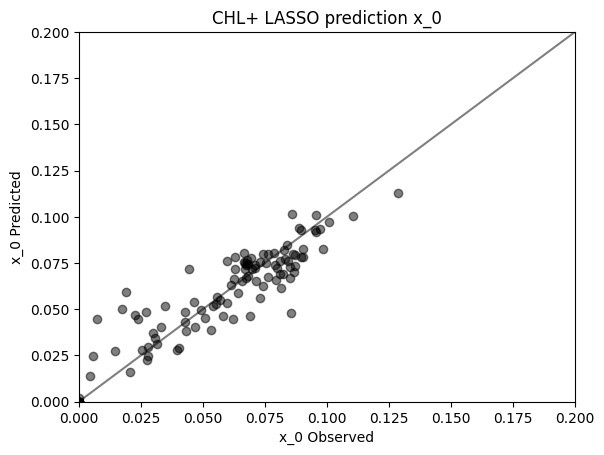

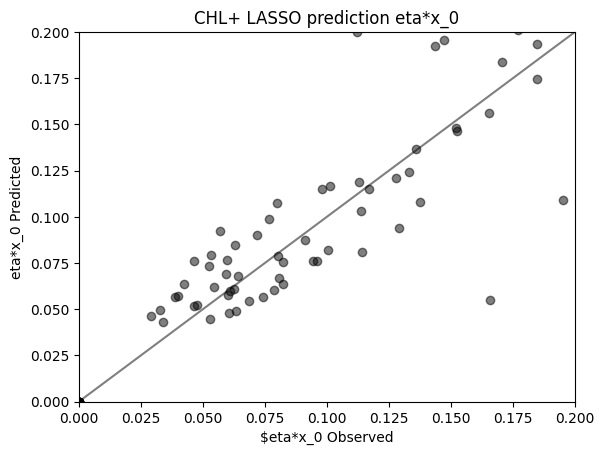

In [25]:

x_nar = np.zeros(110)
y_nar = np.zeros(110)
x_nir = np.zeros(110)
y_nir = np.zeros(110)
x = np.linspace(0,20,10)
y = np.linspace(0,20,10)
for native in range(10):
    for pert in range(11):
        x_nar[10*native + pert] = Y_CHL_POS[native,pert, 0]
        x_nir[10*native + pert] = Y_CHL_POS[native,pert, 1]
        y_nar[10*native + pert] = x0_grid[native, pert]
        y_nir[10*native + pert] = x0_eta_grid[native, pert]
        
plt.scatter(x_nar, y_nar, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('x_0 Observed')
plt.ylabel('x_0 Predicted')
plt.title('CHL+ LASSO prediction x_0')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()
plt.scatter(x_nir, y_nir, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$eta*x_0 Observed')
plt.ylabel('eta*x_0 Predicted')
plt.title('CHL+ LASSO prediction eta*x_0')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()


### Now CHL- 

In [34]:
##############################################################################
### Lasso for NAR, NIR CHL+ case

ALPHA = 0.0001  # Regularization strength

clf_nar = []
clf_nir = []
for i in range(11):
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NAR_CHL_NEG[:,i,:], Y_CHL_NEG[:,i,0])
    clf_nar.append(clf)
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NIR_CHL_NEG[:,i,:], Y_CHL_NEG[:,i,1])
    clf_nir.append(clf)

print("--------------------------------------------------")
print("NAR")
for i in range(11):
    print(f"Coefficients {clf_nar[i].coef_.shape}:\n", clf_nar[i].coef_)
    print(f"Intercepts: {clf_nar[i].intercept_.shape}\n", clf_nar[i].intercept_)
print("--------------------------------------------------")

print("--------------------------------------------------")
print("NIR")
for i in range(11):
    print(f"Coefficients {clf_nir[i].coef_.shape}:\n", clf_nir[i].coef_)
    print(f"Intercepts: {clf_nir[i].intercept_.shape}\n", clf_nir[i].intercept_)
print("--------------------------------------------------")


--------------------------------------------------
NAR
Coefficients (8,):
 [ 0.00254968 -0.         -0.         -0.          0.         -0.
 -0.          0.        ]
Intercepts: ()
 0.009667897962630635
Coefficients (8,):
 [ 0.00018843 -0.         -0.         -0.          0.00315514  0.
 -0.         -0.        ]
Intercepts: ()
 0.009464766217488627
Coefficients (8,):
 [ 0. -0. -0. -0.  0. -0.  0. -0.]
Intercepts: ()
 0.0101651
Coefficients (8,):
 [ 0.00049268 -0.         -0.         -0.         -0.          0.
  0.         -0.        ]
Intercepts: ()
 0.010514422102324115
Coefficients (8,):
 [ 0.00517843  0.         -0.         -0.         -0.00664103  0.
  0.          0.        ]
Intercepts: ()
 0.016596189074851504
Coefficients (8,):
 [ 0.00835104 -0.         -0.         -0.          0.          0.
 -0.         -0.        ]
Intercepts: ()
 0.00939199784305822
Coefficients (8,):
 [ 0.00451083 -0.          0.         -0.00494034 -0.          0.
 -0.          0.        ]
Intercepts: ()


In [35]:
c0_grid = np.zeros((10,11))
c0_eta_grid = np.zeros((10,11))
X_NIR_T0 = nir_rel_exp_chl_neg_t0
X_NAR_T0 = nar_rel_exp_chl_neg_t0
X_NIR_T9 = nir_rel_exp_chl_neg_t9
X_NAR_T9 = nar_rel_exp_chl_neg_t9
for native in tqdm.trange(10, desc="native", leave=False):
        for pert in tqdm.trange(11, desc="perturbed", leave=False):
            c0_pred = 0
            c0_eta_pred = 0
            for i in range(len(group_idxs)):
                c0_pred += X_NAR_T0[native, pert, i]*clf_nar[pert].coef_[i]
                c0_eta_pred += X_NIR_T0[native, pert, i]*clf_nir[pert].coef_[i]  
                c0_pred += X_NAR_T9[native, pert, i]*clf_nar[pert].coef_[i + len(group_idxs)]
                c0_eta_pred += X_NIR_T9[native, pert, i]*clf_nir[pert].coef_[i + len(group_idxs)]  
            c0_pred += clf_nar[pert].intercept_
            c0_eta_pred += clf_nir[pert].intercept_
            y_pred = [c0_pred, c0_eta_pred]
            c0_grid[native, pert] = c0_pred
            c0_eta_grid[native, pert] = c0_eta_pred


native:   0%|          | 0/10 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

...

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

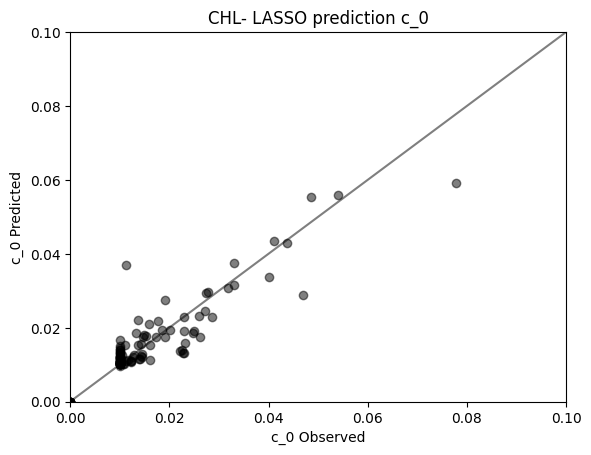

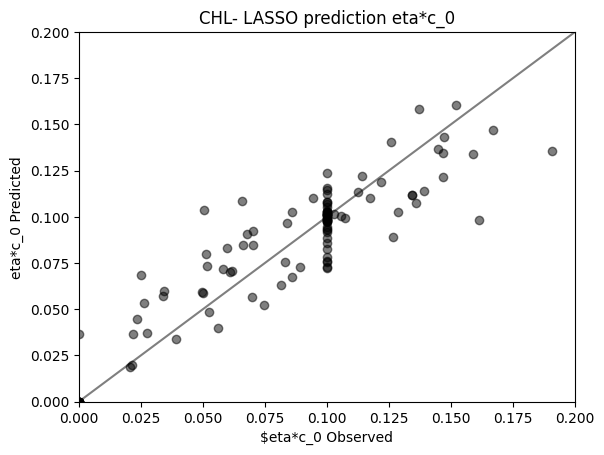

In [37]:

x_nar = np.zeros(110)
y_nar = np.zeros(110)
x_nir = np.zeros(110)
y_nir = np.zeros(110)
x = np.linspace(0,20,10)
y = np.linspace(0,20,10)
for native in range(10):
    for pert in range(11):
        x_nar[10*native + pert] = Y_CHL_NEG[native,pert, 0]
        x_nir[10*native + pert] = Y_CHL_NEG[native,pert, 1]
        y_nar[10*native + pert] = c0_grid[native, pert]
        y_nir[10*native + pert] = c0_eta_grid[native, pert]
        
plt.scatter(x_nar, y_nar, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('c_0 Observed')
plt.ylabel('c_0 Predicted')
plt.title('CHL- LASSO prediction c_0')
plt.xlim(0,0.1)
plt.ylim(0,0.1)
plt.show()
plt.scatter(x_nir, y_nir, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$eta*c_0 Observed')
plt.ylabel('eta*c_0 Predicted')
plt.title('CHL- LASSO prediction eta*c_0')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()


### Try a LOOCV on all of the data

In [29]:
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

ALPHA = 0.05  # Regularization strength

# Flatten data
X_nar_all = X_NAR_CHL_POS.reshape(-1, X_NAR_CHL_POS.shape[-1])  # (110, number clusters)
X_nir_all = X_NIR_CHL_POS.reshape(-1, X_NIR_CHL_POS.shape[-1])  # (110, number clusters)
y_nar_all = Y_CHL_POS[:, :, 0].flatten()  # (110,)
y_nir_all = Y_CHL_POS[:, :, 1].flatten()  # (110,)

# Initialize prediction arrays
nar_predictions = np.zeros_like(y_nar_all)
nir_predictions = np.zeros_like(y_nir_all)

# Leave-one-out CV over ALL 110 points
for i in range(len(y_nar_all)):
    # Train NAR model on all points EXCEPT i
    X_train = np.delete(X_nar_all, i, axis=0)
    y_train = np.delete(y_nar_all, i)
    clf = linear_model.Lasso(alpha=ALPHA).fit(X_train, y_train)
    nar_predictions[i] = clf.predict(X_nar_all[i].reshape(1, -1))
    
    # Train NIR model on all points EXCEPT i
    X_train = np.delete(X_nir_all, i, axis=0)
    y_train = np.delete(y_nir_all, i)
    clf = linear_model.Lasso(alpha=ALPHA).fit(X_train, y_train)
    nir_predictions[i] = clf.predict(X_nir_all[i].reshape(1, -1))

# Reshape predictions back to (10, 11) for per-perturbation analysis
nar_predictions = nar_predictions.reshape(10, 11)
nir_predictions = nir_predictions.reshape(10, 11)

nar_predictions_chl_pos = nar_predictions
nir_predictions_chl_pos = nir_predictions

# Compute errors (MSE and MAE per perturbation)
nar_mse = [mean_squared_error(Y_CHL_POS[:, i, 0], nar_predictions[:, i]) for i in range(11)]
nir_mse = [mean_squared_error(Y_CHL_POS[:, i, 1], nir_predictions[:, i]) for i in range(11)]

nar_mae = [mean_absolute_error(Y_CHL_POS[:, i, 0], nar_predictions[:, i]) for i in range(11)]
nir_mae = [mean_absolute_error(Y_CHL_POS[:, i, 1], nir_predictions[:, i]) for i in range(11)]

print("NAR Mean Squared Error:")
print(np.round(nar_mse, 4))
print("\nNIR Mean Squared Error:")
print(np.round(nir_mse, 4))

NAR Mean Squared Error:
[0.0013 0.0008 0.0006 0.0005 0.0005 0.0004 0.0006 0.0007 0.0009 0.0007
 0.0009]

NIR Mean Squared Error:
[0.0597 0.0243 0.0507 0.0589 0.0206 0.0053 0.0059 0.0109 0.0142 0.0173
 0.0118]


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_1288/501996226.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nar_predictions[i] = clf.predict(X_nar_all[i].reshape(1, -1))
/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_1288/501996226.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nir_predictions[i] = clf.predict(X_nir_all[i].reshape(1, -1))
/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_1288/501996226.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this op

In [ ]:
plot((nar_predictions_chl_pos - Y_CHL_POS[:, :, 0])**2/Y_CHL_POS[:, :, 0]**2, 'Squared Relative Nar Error, CHL+', cmap = 'Reds', vmin = 0, vmax = 1)
plot((nir_predictions_chl_pos - Y_CHL_POS[:, :, 1])**2/Y_CHL_POS[:, :, 1]**2, 'Squared Relative Nir Error, CHL+', cmap = 'Reds', vmin = 0, vmax = 1)


x_nar = np.zeros(110)
y_nar = np.zeros(110)
x_nir = np.zeros(110)
y_nir = np.zeros(110)
x = np.linspace(0,20,10)
y = np.linspace(0,20,10)
for native in range(10):
    for pert in range(11):
        x_nar[10*native + pert] = Y_CHL_POS[native,pert, 0]
        x_nir[10*native + pert] = Y_CHL_POS[native,pert, 1]
        y_nar[10*native + pert] = nar_predictions_chl_pos[native, pert]
        y_nir[10*native + pert] = nir_predictions_chl_pos[native, pert]
        
plt.scatter(x_nar, y_nar, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('rA Observed')
plt.ylabel('rA Predicted')
plt.xlim(0,5)
plt.ylim(0,5)
plt.show()
plt.scatter(x_nir, y_nir, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('rI Observed')
plt.ylabel('rI Predicted')
plt.xlim(0,20)
plt.ylim(0,20)
plt.show()
